In [4]:
from tqdm import tqdm
import os
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.util import ngrams
from nltk.corpus import stopwords
from wordcloud import WordCloud
import re

from librispeech import get_dataset_iterator_librispeech

In [5]:
dataset_items = list(get_dataset_iterator_librispeech())

df = pd.DataFrame([{
        'file': item.file,
        'id': item.id,
        'audio': item.audio, 
        'text': item.text, 
    } for item in dataset_items])

df.head()

Loading Librispeech dataset...


Processing samples: 2703it [00:44, 60.26it/s] 


,file,id,audio,text
0,2277-149896-0000.flac,2277-149896-0000,"{'path': '2277-149896-0000.flac', 'array': [0....",HE WAS IN A FEVERED STATE OF MIND OWING TO THE...
1,2277-149896-0001.flac,2277-149896-0001,"{'path': '2277-149896-0001.flac', 'array': [0....",HE WOULD HAVE TO PAY HER THE MONEY WHICH SHE W...
2,2277-149896-0002.flac,2277-149896-0002,"{'path': '2277-149896-0002.flac', 'array': [0....",HURSTWOOD WALKED THE FLOOR MENTALLY ARRANGING ...
3,2277-149896-0003.flac,2277-149896-0003,"{'path': '2277-149896-0003.flac', 'array': [0....",HE ALSO THOUGHT OF HIS MANAGERIAL POSITION
4,2277-149896-0004.flac,2277-149896-0004,"{'path': '2277-149896-0004.flac', 'array': [0....",HOW WOULD THE PAPERS TALK ABOUT IT


In [6]:
df['audio_path'] = df['audio'].apply(lambda x: x['path'])
df['audio_array'] = df['audio'].apply(lambda x: x['array'])
df['sampling_rate'] = df['audio'].apply(lambda x: x['sampling_rate'])

In [7]:
df.drop(columns=['audio'], inplace=True)

In [8]:
df.head()

,file,id,text,audio_path,audio_array,sampling_rate
0,2277-149896-0000.flac,2277-149896-0000,HE WAS IN A FEVERED STATE OF MIND OWING TO THE...,2277-149896-0000.flac,"[0.001861572265625, 0.000518798828125, 0.00024...",16000
1,2277-149896-0001.flac,2277-149896-0001,HE WOULD HAVE TO PAY HER THE MONEY WHICH SHE W...,2277-149896-0001.flac,"[0.00115966796875, -0.00042724609375, 0.000823...",16000
2,2277-149896-0002.flac,2277-149896-0002,HURSTWOOD WALKED THE FLOOR MENTALLY ARRANGING ...,2277-149896-0002.flac,"[0.000823974609375, 0.000701904296875, 0.00067...",16000
3,2277-149896-0003.flac,2277-149896-0003,HE ALSO THOUGHT OF HIS MANAGERIAL POSITION,2277-149896-0003.flac,"[0.000732421875, 0.000274658203125, 0.00051879...",16000
4,2277-149896-0004.flac,2277-149896-0004,HOW WOULD THE PAPERS TALK ABOUT IT,2277-149896-0004.flac,"[0.00048828125, 0.00103759765625, 0.0018615722...",16000


### Смотрим на длительнось аудио

In [9]:
df['duration'] = df.apply(lambda row: len(row['audio_array']) / row['sampling_rate'] if row['sampling_rate'] > 0 else 0, axis=1)

print("\nDuration Statistics:")
print(df['duration'].describe())


Duration Statistics:
count    2703.000000
mean        7.175775
std         4.695612
min         1.445000
25%         3.760000
50%         5.920000
75%         9.267500
max        32.645000
Name: duration, dtype: float64


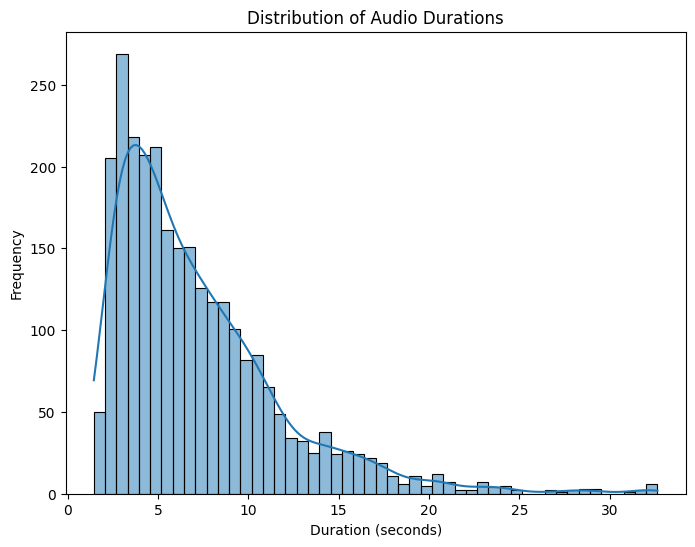

In [10]:
plt.figure(figsize=(8,6))
sns.histplot(df['duration'], bins=50, kde=True)
plt.title('Distribution of Audio Durations')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.show()

### Смотрим на текст

In [11]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [12]:
df['tokens'] = df['clean_text'].apply(nltk.word_tokenize)
df['transcript_length'] = df['tokens'].apply(len)

In [13]:
print("\nTranscript Length Statistics:")
print(df['transcript_length'].describe())


Transcript Length Statistics:
count    2703.000000
mean       20.132075
std        13.530319
min         1.000000
25%        10.000000
50%        17.000000
75%        26.000000
max        92.000000
Name: transcript_length, dtype: float64


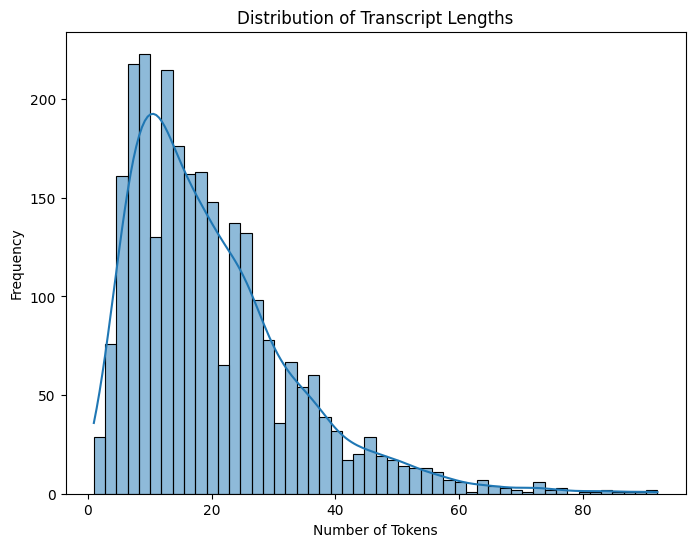

In [14]:
plt.figure(figsize=(8,6))
sns.histplot(df['transcript_length'], bins=50, kde=True)
plt.title('Distribution of Transcript Lengths')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.show()

In [16]:
# Большой размер словаря
all_tokens = [token for tokens in df['tokens'] for token in tokens]
vocab = set(all_tokens)
print("\nVocabulary Size:", len(vocab))


Vocabulary Size: 8297


### Смотрим N-граммы

In [17]:
bigrams = list(ngrams(all_tokens, 2))
bigram_counts = Counter(bigrams)
print("\nTop 20 Most Common Bigrams:")
print(bigram_counts.most_common(20))


Top 20 Most Common Bigrams:
[(('of', 'the'), 423), (('in', 'the'), 265), (('to', 'the'), 176), (('on', 'the'), 125), (('and', 'the'), 124), (('it', 'was'), 110), (('in', 'a'), 92), (('of', 'a'), 87), (('at', 'the'), 85), (('of', 'his'), 84), (('it', 'is'), 76), (('with', 'the'), 75), (('to', 'be'), 74), (('he', 'was'), 70), (('for', 'the'), 69), (('with', 'a'), 68), (('had', 'been'), 66), (('he', 'had'), 64), (('by', 'the'), 62), (('all', 'the'), 60)]


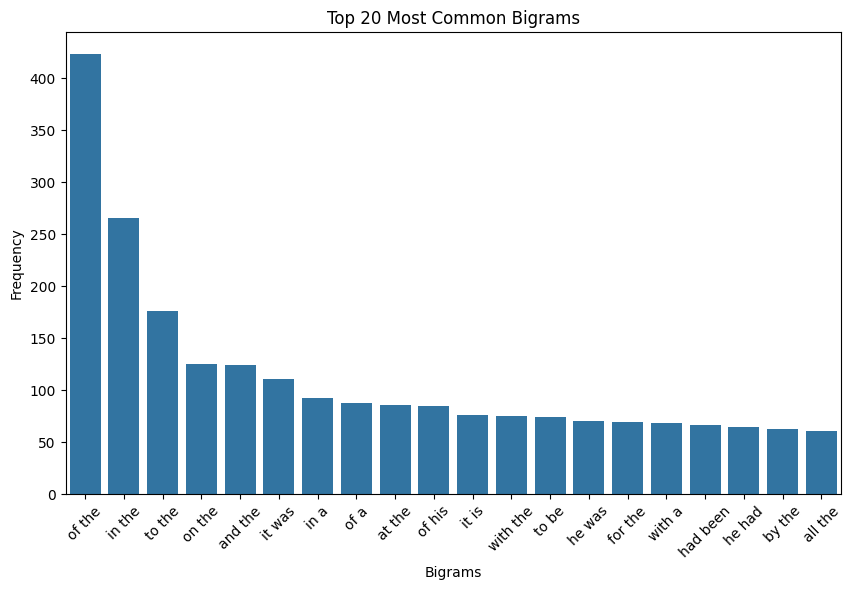

In [18]:
top_bigrams = bigram_counts.most_common(20)
bigrams_list, bigram_freq = zip(*top_bigrams)
bigrams_joined = [' '.join(bigram) for bigram in bigrams_list]

plt.figure(figsize=(10,6))
sns.barplot(x=list(bigrams_joined), y=list(bigram_freq))
plt.title('Top 20 Most Common Bigrams')
plt.xlabel('Bigrams')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

In [19]:
def generate_ngram_wordcloud(tokens_list, n, max_words):
    ngram_counts = Counter()
    for tokens in tokens_list:
        ngram_counts.update(ngrams(tokens, n))
    
    ngram_freq = {' '.join(gram): count for gram, count in ngram_counts.items()}
    wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=max_words).generate_from_frequencies(ngram_freq)
    
    plt.figure(figsize=(15, 7.5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud of {n}-grams in text', fontsize=20)
    plt.show()

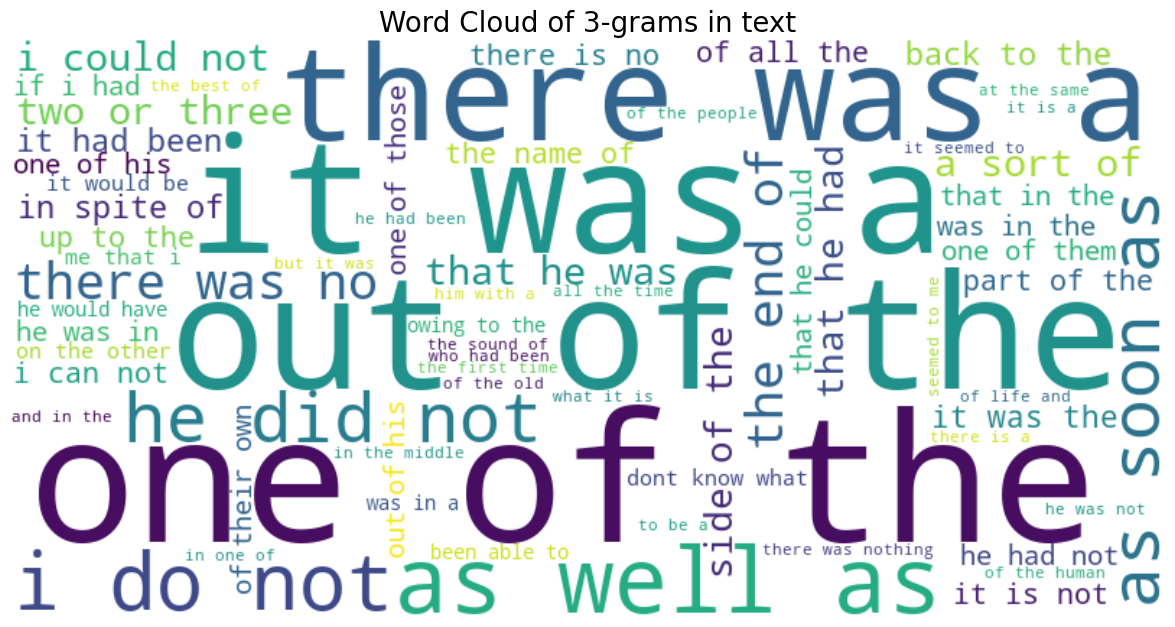

In [20]:
generate_ngram_wordcloud(df['tokens'], n=3, max_words=70)